# Guitar Pieces Dataset Analysis
This notebook analyzes the `guitarburst_csv.json` dataset to understand the distribution of found and unfound pieces, specifically focusing on difficulty levels and top composers.

In [ ]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

print(f"Current Working Directory: {os.getcwd()}")

# Load the dataset
try:
    with open('features/guitarburst_csv.json', 'r') as f:
        data = json.load(f)
    print("Successfully loaded features/guitarburst_csv.json")
except FileNotFoundError:
    with open('guitarburst_csv.json', 'r') as f:
        data = json.load(f)
    print("Successfully loaded guitarburst_csv.json")

df = pd.DataFrame(data)

# Data Cleaning
df['Difficulty'] = pd.to_numeric(df['Difficulty'], errors='coerce')
df['Composer'] = df['Composer'].str.strip()

# Summary Stats
print(f"Total pieces: {len(df)}")
print(f"Found: {len(df[df['status'] == 'found'])}")
print(f"Unfound: {len(df[df['status'] == 'not_found'])}")


Current Working Directory: /home/aser/programming/thesis/rubricnet/features
Successfully loaded guitarburst_csv.json
Total pieces: 2335
Found: 650
Unfound: 1685


## Difficulty Distribution of Found Pieces
This plot shows the difficulty levels of the pieces we have successfully found.

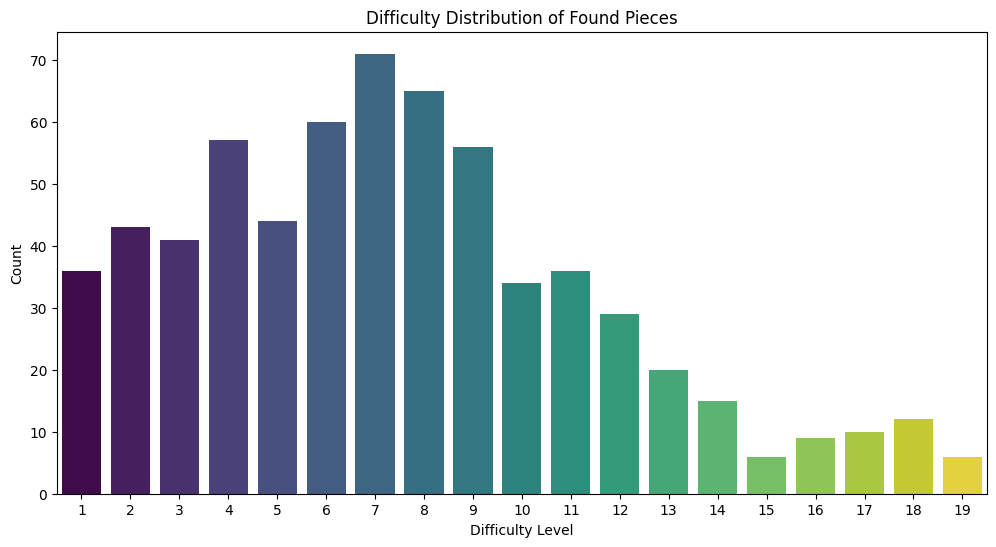

In [ ]:
plt.figure(figsize=(12, 6))
found_df = df[df['status'] == 'found']
sns.countplot(data=found_df, x='Difficulty', hue='Difficulty', palette='viridis', legend=False)
plt.title('Difficulty Distribution of Found Pieces')
plt.xlabel('Difficulty Level')
plt.ylabel('Count')
plt.show()

## Difficulty Distribution for Top 10 Composers (Unfound)
Let's see the difficulty spread for the composers with the most missing pieces.

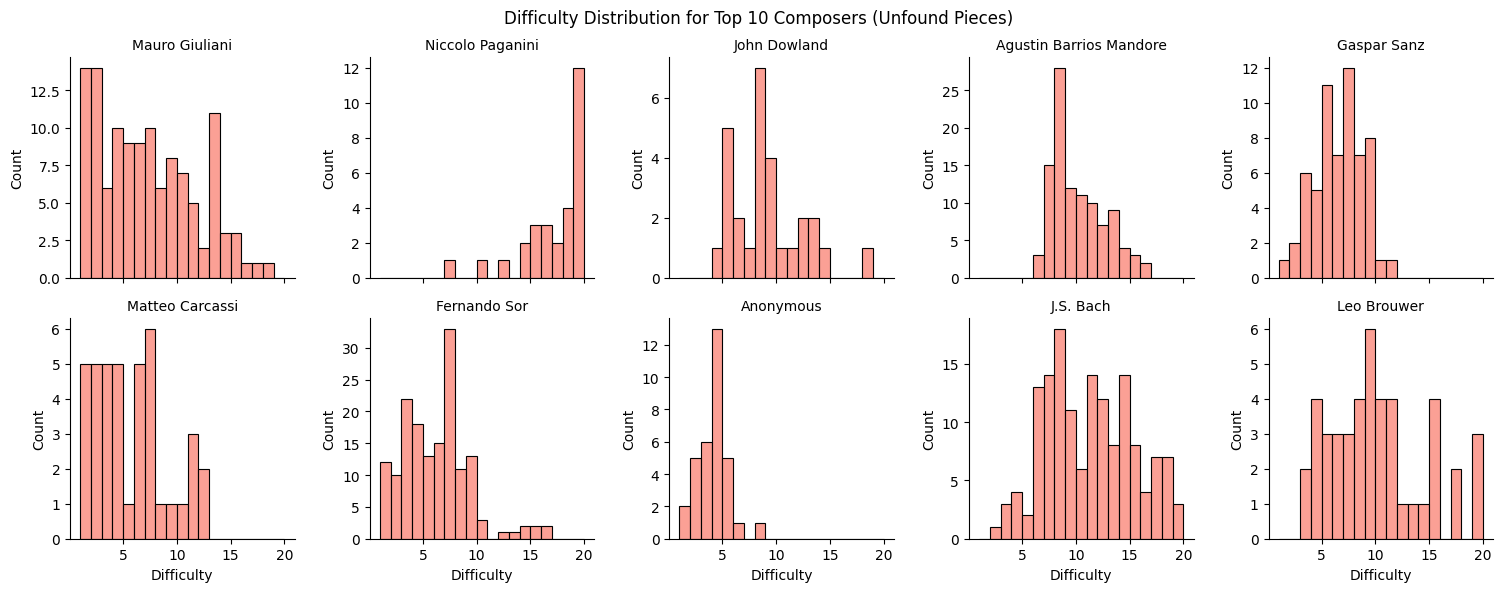

In [ ]:
unfound_df = df[df['status'] == 'not_found']
top_10_composers = unfound_df['Composer'].value_counts().head(10).index.tolist()
subset_unfound = unfound_df[unfound_df['Composer'].isin(top_10_composers)]

g = sns.FacetGrid(subset_unfound, col="Composer", col_wrap=5, height=3, sharex=True, sharey=False)
g.map(sns.histplot, "Difficulty", bins=range(1, 21), kde=False, color='salmon')
g.set_titles("{col_name}")
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('Difficulty Distribution for Top 10 Composers (Unfound Pieces)')
plt.show()

## Is Paganini the "Best Bet"?
The user asked if Paganini is the best bet. Let's look at his specific distribution.

Total Paganini pieces: 33
Found: 4
Unfound: 29


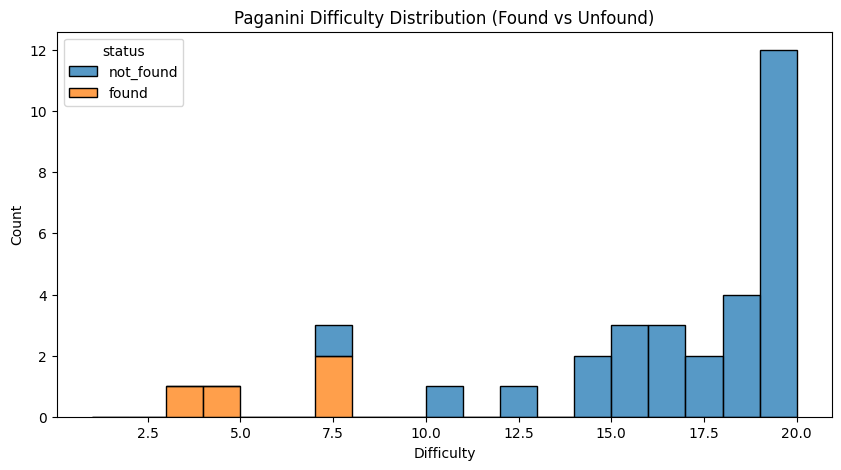

In [ ]:
paganini_df = df[df['Composer'].str.contains('Paganini', case=False, na=False)]
print(f"Total Paganini pieces: {len(paganini_df)}")
print(f"Found: {len(paganini_df[paganini_df['status'] == 'found'])}")
print(f"Unfound: {len(paganini_df[paganini_df['status'] == 'not_found'])}")

plt.figure(figsize=(10, 5))
sns.histplot(data=paganini_df, x='Difficulty', hue='status', multiple='stack', bins=range(1, 21))
plt.title('Paganini Difficulty Distribution (Found vs Unfound)')
plt.show()